In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [72]:
# Load and preprocess the dataset
df = pd.read_csv('auto-mpg.data', delim_whitespace=True, header=None, na_values='?')
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df.drop('car_name', axis=1, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

/var/folders/lr/rqpgb0714cx2sytn8gyfflq40000gn/T/ipykernel_24954/3374945800.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('auto-mpg.data', delim_whitespace=True, header=None, na_values='?')
/var/folders/lr/rqpgb0714cx2sytn8gyfflq40000gn/T/ipykernel_24954/3374945800.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


In [73]:
X = df.drop('mpg', axis=1)
y = df['mpg']

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [75]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [76]:
# 2L Neural Network (zero hidden layers)
class NN_2L(nn.Module):
    def __init__(self, input_dim):
        super(NN_2L, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [77]:
# 3L Neural Network (one hidden layer)
class NN_3L(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super(NN_3L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)

In [78]:
# 4L Neural Network (two hidden layers)
class NN_4L(nn.Module):
    def __init__(self, input_dim, hidden1=32, hidden2=16):
        super(NN_4L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.model(x)

In [79]:
# Picked architecture
class NN_5L(nn.Module):
    def __init__(self, input_dim, h1=64, h2=32, h3=16):
        super(NN_5L, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            
            nn.Linear(h1, h2),
            nn.ReLU(),
            
            nn.Linear(h2, h3),
            nn.ReLU(),
            
            nn.Linear(h3, 1)
        )

    def forward(self, x):
        return self.model(x)

In [54]:
""" def train_model(model, train_loader, epochs=200, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            predictions = model(xb)
            loss = criterion(predictions, yb)
            loss.backward()
            optimizer.step()

In [80]:
def train_model(model, train_loader, X_test_tensor, y_test_tensor, epochs=200, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            predictions = model(xb)
            loss = criterion(predictions, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # validation loss
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_test_tensor)
            val_loss = criterion(val_predictions, y_test_tensor).item()
            val_losses.append(val_loss)

    return train_losses, val_losses

In [81]:
def evaluate_model(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        predictions = model(X_data).numpy().flatten()
        actual = y_data.numpy().flatten()

    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predictions)

    return mse, rmse, r2

In [82]:
def plot_loss(train_losses, val_losses, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

In [83]:
def run_model(model_name, model):
    # train_model(model, train_loader)
    train_losses, val_losses = train_model(model, train_loader, X_test_tensor, y_test_tensor)

    train_mse, train_rmse, train_r2 = evaluate_model(model, X_train_tensor, y_train_tensor)
    test_mse, test_rmse, test_r2 = evaluate_model(model, X_test_tensor, y_test_tensor)

    print(f"\n{model_name}")
    print("In-Sample:")
    print(f"MSE  = {train_mse:.4f}")
    print(f"RMSE = {train_rmse:.4f}")
    print(f"R^2  = {train_r2:.4f}")

    print("Validation:")
    print(f"MSE  = {test_mse:.4f}")
    print(f"RMSE = {test_rmse:.4f}")
    print(f"R^2  = {test_r2:.4f}")

    plot_loss(train_losses, val_losses, model_name)


2L Neural Network (zero hidden layers)
In-Sample:
MSE  = 70.7048
RMSE = 8.4086
R^2  = -0.1277
Validation:
MSE  = 71.1794
RMSE = 8.4368
R^2  = -0.3239


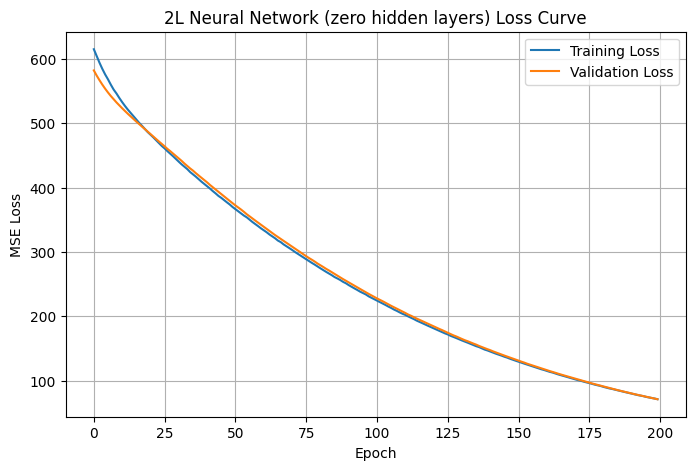


3L Neural Network (one hidden layer)
In-Sample:
MSE  = 6.6785
RMSE = 2.5843
R^2  = 0.8935
Validation:
MSE  = 4.6612
RMSE = 2.1590
R^2  = 0.9133


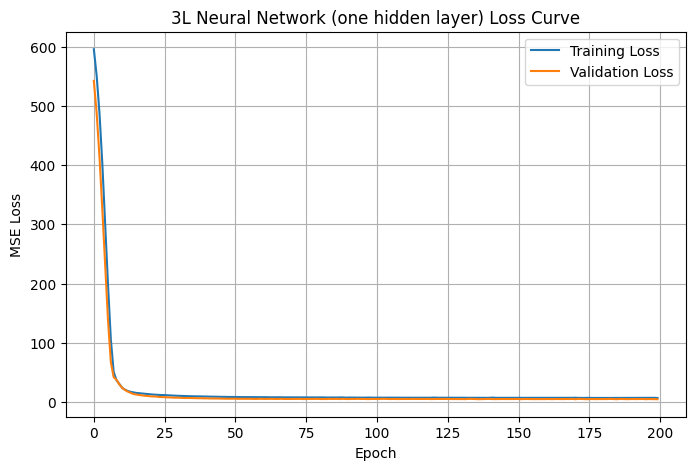


4L Neural Network (two hidden layers)
In-Sample:
MSE  = 5.8248
RMSE = 2.4135
R^2  = 0.9071
Validation:
MSE  = 4.5723
RMSE = 2.1383
R^2  = 0.9150


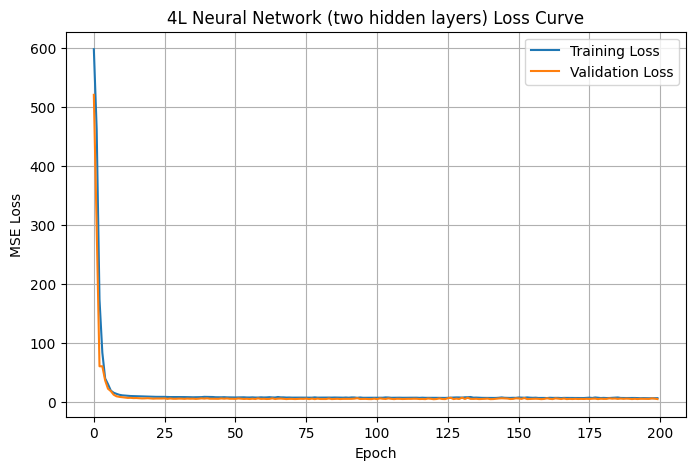


5L Neural Network (three hidden layers)
In-Sample:
MSE  = 3.7912
RMSE = 1.9471
R^2  = 0.9395
Validation:
MSE  = 6.2571
RMSE = 2.5014
R^2  = 0.8836


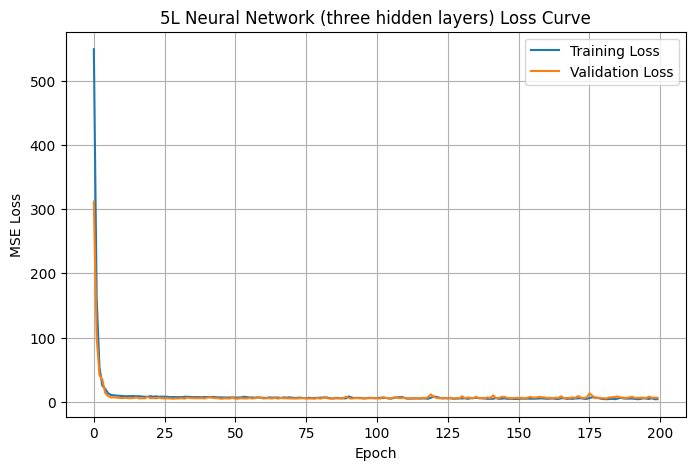

In [84]:
input_dim = X_train.shape[1]

model_2l = NN_2L(input_dim)
model_3l = NN_3L(input_dim, hidden_dim=16)
model_4l = NN_4L(input_dim, hidden1=32, hidden2=16)
model_5l = NN_5L(input_dim, h1=64, h2=32, h3=16)

run_model("2L Neural Network (zero hidden layers)", model_2l)
run_model("3L Neural Network (one hidden layer)", model_3l)
run_model("4L Neural Network (two hidden layers)", model_4l)
run_model("5L Neural Network (three hidden layers)", model_5l)